# Double Descent in Polynomial Curve Fitting (JAX Version)

This notebook demonstrates the **double descent** phenomenon in polynomial regression using **JAX** for improved reproducibility.

## Why JAX?

JAX provides better reproducibility than NumPy through:
- **Explicit PRNG keys**: No global random state; every random operation receives a specific key
- **Platform independence**: Same results on CPU/GPU/TPU
- **Functional design**: Pure functions are deterministic by construction

## Overview

Classical statistical learning theory predicts a U-shaped curve for test error as model complexity increases. However, modern machine learning models often operate in the **overparameterized regime** where the number of parameters exceeds the number of training samples.

The **double descent** curve shows that after the peak at the interpolation threshold, test error *decreases* again in the overparameterized regime.

## Experimental Setup

- **Ground truth**: $f(x) = \sin(2\pi x)$ (non-polynomial function)
- **Training data**: 5 points with 30% Gaussian noise
- **Model**: Legendre polynomial basis of degrees 1-14
- **Interpolation threshold**: Degree 4 (5 parameters = 5 data points)

In [ ]:
# Colab setup - run this cell first if using Google Colab
import sys, os

if 'google.colab' in sys.modules:
    repo_dir = '/content/CompMathAndAICourse/'
    if not os.path.exists(repo_dir):
        !git clone https://github.com/lruthotto/CompMathAndAICourse.git {repo_dir}
        %pip install -q jax jaxlib
    
    sys.path.append(repo_dir)
    os.chdir(repo_dir)
    print(f"Running on Colab, repo cloned to {repo_dir}")

In [11]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

# Check JAX backend
print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")

# Master PRNG key for reproducibility
MASTER_KEY = random.PRNGKey(42)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

JAX version: 0.8.1
Backend: cpu


## 1. Helper Functions

All functions are implemented in JAX with explicit PRNG key handling.

In [ ]:
def ground_truth(x):
    """
    Non-polynomial ground truth function: f(x) = sin(2*pi*x)
    """
    return jnp.sin(2 * jnp.pi * x)


def legendre_basis(x, degree):
    """
    Compute Legendre polynomial basis up to specified degree in a single pass.

    Uses the three-term recurrence relation:
        P_0(x) = 1
        P_1(x) = x
        P_{k+1}(x) = ((2k+1)*x*P_k(x) - k*P_{k-1}(x)) / (k+1)

    Args:
        x: Points at which to evaluate (array-like)
        degree: Maximum polynomial degree

    Returns:
        Design matrix Phi of shape (len(x), degree+1)
        where Phi[:, k] = P_k(x) is the k-th Legendre polynomial
    """
    x = jnp.asarray(x)
    n = len(x)

    # Pre-allocate the full design matrix
    Phi = jnp.zeros((n, degree + 1))

    # P_0(x) = 1
    Phi = Phi.at[:, 0].set(jnp.ones(n))

    if degree >= 1:
        # P_1(x) = x
        Phi = Phi.at[:, 1].set(x)

    # Compute remaining polynomials using recurrence (single pass, O(degree))
    for k in range(1, degree):
        # P_{k+1}(x) = ((2k+1)*x*P_k(x) - k*P_{k-1}(x)) / (k+1)
        p_next = ((2*k + 1) * x * Phi[:, k] - k * Phi[:, k-1]) / (k + 1)
        Phi = Phi.at[:, k+1].set(p_next)

    return Phi


def fit_polynomial(x_train, y_train, degree):
    """
    Fit Legendre polynomial using minimum norm solution (pseudoinverse).

    For underdetermined systems, this returns the minimum L2 norm solution,
    providing implicit regularization.
    """
    Phi = legendre_basis(x_train, degree)
    coeffs, _, _, _ = jnp.linalg.lstsq(Phi, y_train, rcond=None)
    return coeffs


def evaluate_polynomial(x, coeffs):
    """
    Evaluate fitted polynomial at given points.
    """
    degree = len(coeffs) - 1
    Phi = legendre_basis(x, degree)
    return Phi @ coeffs


def compute_l2_relative_error(coeffs, x_grid, y_true_grid):
    """
    Compute L2 relative error using trapezoidal integration.

    ||f_fit - f_true||_2 / ||f_true||_2
    """
    y_pred_grid = evaluate_polynomial(x_grid, coeffs)
    dx = x_grid[1] - x_grid[0]
    error_norm = jnp.sqrt(jnp.trapezoid((y_pred_grid - y_true_grid)**2, dx=dx))
    true_norm = jnp.sqrt(jnp.trapezoid(y_true_grid**2, dx=dx))
    return error_norm / true_norm


def compute_solution_norm(coeffs):
    """Compute L2 norm of solution coefficients."""
    return jnp.linalg.norm(coeffs)

## 2. Generate Training Data with Explicit PRNG Keys

Each noise realization gets its own PRNG key, ensuring full reproducibility.

In [13]:
# Configuration
X_MIN, X_MAX = -1.0, 1.0
N_TRAIN = 5
N_VAL = 5
N_TOTAL = N_TRAIN + N_VAL
NOISE_LEVEL = 0.30  # 30% of signal range

# Polynomial degrees to test
MIN_DEGREE = 1
MAX_DEGREE = 14
N_REALIZATIONS = 50

# Generate data points (interleaved train/val split)
x_all = jnp.linspace(X_MIN, X_MAX, N_TOTAL)
y_all_clean = ground_truth(x_all)

# Split: train gets even indices, val gets odd indices
train_indices = jnp.arange(0, N_TOTAL, 2)[:N_TRAIN]
x_train = x_all[train_indices]
y_train_clean = y_all_clean[train_indices]

# Compute noise standard deviation
signal_range = float(y_all_clean.max() - y_all_clean.min())
noise_std = NOISE_LEVEL * signal_range

# Fine grid for L2 error computation
x_fine = jnp.linspace(X_MIN, X_MAX, 500)
y_fine = ground_truth(x_fine)

print(f"Training points: {N_TRAIN}")
print(f"x_train: {x_train}")
print(f"Noise std: {noise_std:.4f} ({NOISE_LEVEL*100}% of signal range)")
print(f"Polynomial degrees: {MIN_DEGREE} to {MAX_DEGREE}")
print(f"Interpolation threshold: degree {N_TRAIN - 1}")
print(f"\nPRNG Master Key: {MASTER_KEY}")

Training points: 5
x_train: [-1.         -0.5555556  -0.11111113  0.33333337  0.7777778 ]
Noise std: 0.5909 (30.0% of signal range)
Polynomial degrees: 1 to 14
Interpolation threshold: degree 4

PRNG Master Key: [ 0 42]


### Visualize the Problem Setup

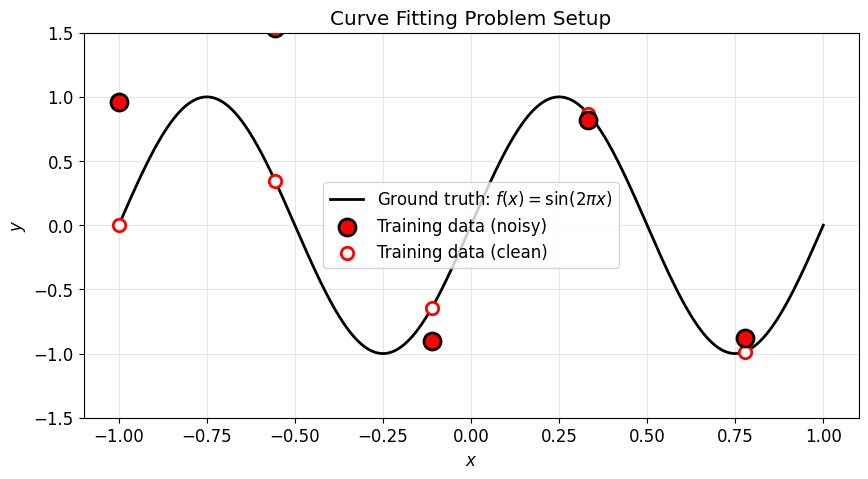

In [14]:
# Generate one noisy realization for visualization (with explicit key)
viz_key = random.PRNGKey(0)
y_train_noisy_example = y_train_clean + random.normal(viz_key, shape=(N_TRAIN,)) * noise_std

plt.figure(figsize=(10, 5))
plt.plot(x_fine, y_fine, 'k-', linewidth=2, label='Ground truth: $f(x) = \\sin(2\\pi x)$')
plt.scatter(x_train, y_train_noisy_example, s=150, c='red', marker='o',
            edgecolors='black', linewidths=2, label='Training data (noisy)', zorder=5)
plt.scatter(x_train, y_train_clean, s=80, c='white', marker='o',
            edgecolors='red', linewidths=2, label='Training data (clean)', zorder=4)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Curve Fitting Problem Setup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.5, 1.5)
plt.show()

## 3. Run the Double Descent Experiment

Each noise realization uses a unique PRNG key derived from the master key.

In [15]:
degrees = jnp.arange(MIN_DEGREE, MAX_DEGREE + 1)
n_degrees = len(degrees)

# Pre-generate all noise keys for full reproducibility
noise_keys = random.split(MASTER_KEY, N_REALIZATIONS)

# Storage for results (using numpy for mutation, convert back at end)
import numpy as np
val_errors = np.zeros((n_degrees, N_REALIZATIONS))
solution_norms = np.zeros((n_degrees, N_REALIZATIONS))

# Store representative coefficients (first realization)
representative_coeffs = {}
representative_y_train = None

print("Running experiment with explicit PRNG keys...")
for j in range(N_REALIZATIONS):
    # Generate noise with this realization's key
    noise = random.normal(noise_keys[j], shape=(N_TRAIN,)) * noise_std
    y_train_noisy = y_train_clean + noise

    # Store first realization for visualization
    if j == 0:
        representative_y_train = y_train_noisy

    for i, degree in enumerate(degrees):
        # Fit polynomial
        coeffs = fit_polynomial(x_train, y_train_noisy, int(degree))

        # Compute metrics
        val_errors[i, j] = float(compute_l2_relative_error(coeffs, x_fine, y_fine))
        solution_norms[i, j] = float(compute_solution_norm(coeffs))

        # Store first fit as representative
        if j == 0:
            representative_coeffs[int(degree)] = coeffs

print("Done!")

# Compute summary statistics
val_mean = np.mean(val_errors, axis=1)
val_std = np.std(val_errors, axis=1)
norm_mean = np.mean(solution_norms, axis=1)
norm_std = np.std(solution_norms, axis=1)

Running experiment with explicit PRNG keys...
Done!


## 4. Visualize the Double Descent Curve

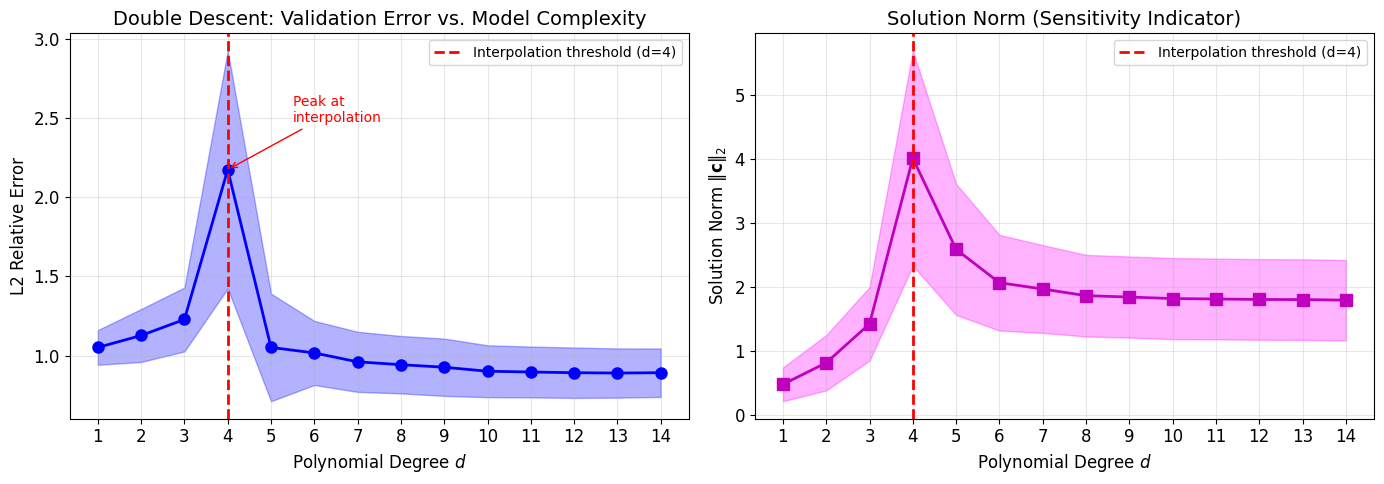


KEY OBSERVATIONS

At interpolation threshold (degree 4):
  Validation error: 2.1733 +/- 0.7493
  Solution norm:    4.0175 +/- 1.6810

Minimum validation error at degree 13:
  Validation error: 0.8908 +/- 0.1553


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

interp_degree = N_TRAIN - 1  # Interpolation threshold
degrees_np = np.array(degrees)

# Left: Validation error (Double Descent curve)
ax1.plot(degrees_np, val_mean, 'b-', linewidth=2, marker='o', markersize=8)
ax1.fill_between(degrees_np, val_mean - val_std, val_mean + val_std, alpha=0.3, color='blue')
ax1.axvline(interp_degree, color='red', linestyle='--', linewidth=2,
            label=f'Interpolation threshold (d={interp_degree})')
ax1.set_xlabel('Polynomial Degree $d$', fontsize=12)
ax1.set_ylabel('L2 Relative Error', fontsize=12)
ax1.set_title('Double Descent: Validation Error vs. Model Complexity', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(degrees_np)

# Annotate key points
ax1.annotate('Peak at\ninterpolation', xy=(interp_degree, val_mean[interp_degree-1]),
             xytext=(interp_degree + 1.5, val_mean[interp_degree-1] + 0.3),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

# Right: Solution norm
ax2.plot(degrees_np, norm_mean, 'm-', linewidth=2, marker='s', markersize=8)
ax2.fill_between(degrees_np, norm_mean - norm_std, norm_mean + norm_std, alpha=0.3, color='magenta')
ax2.axvline(interp_degree, color='red', linestyle='--', linewidth=2,
            label=f'Interpolation threshold (d={interp_degree})')
ax2.set_xlabel('Polynomial Degree $d$', fontsize=12)
ax2.set_ylabel('Solution Norm $\\|\\mathbf{c}\\|_2$', fontsize=12)
ax2.set_title('Solution Norm (Sensitivity Indicator)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(degrees_np)

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "="*60)
print("KEY OBSERVATIONS")
print("="*60)
print(f"\nAt interpolation threshold (degree {interp_degree}):")
print(f"  Validation error: {val_mean[interp_degree-1]:.4f} +/- {val_std[interp_degree-1]:.4f}")
print(f"  Solution norm:    {norm_mean[interp_degree-1]:.4f} +/- {norm_std[interp_degree-1]:.4f}")

min_val_idx = np.argmin(val_mean)
print(f"\nMinimum validation error at degree {degrees_np[min_val_idx]}:")
print(f"  Validation error: {val_mean[min_val_idx]:.4f} +/- {val_std[min_val_idx]:.4f}")

## 5. Visualize Representative Fits

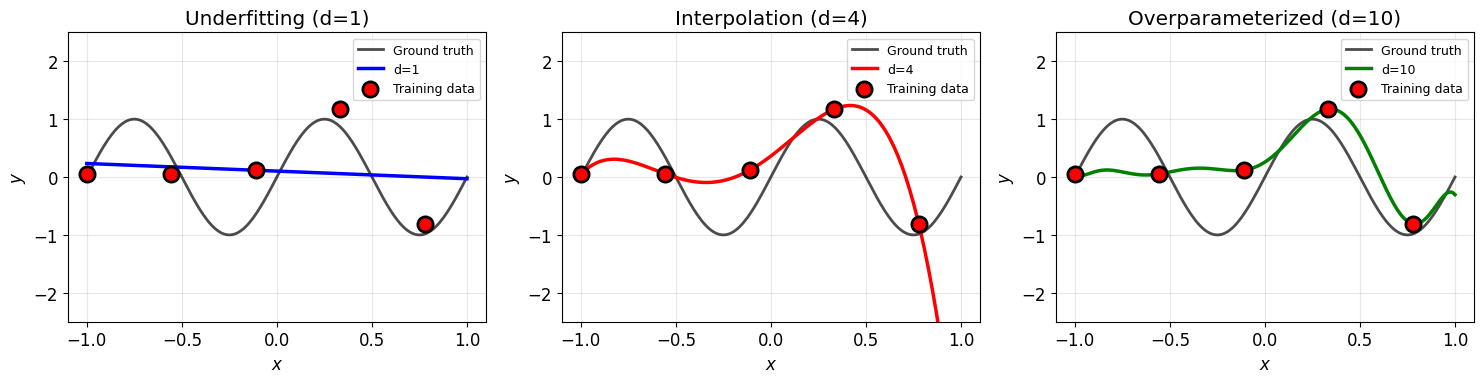

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

key_degrees = [1, 4, 10]
titles = ['Underfitting (d=1)', 'Interpolation (d=4)', 'Overparameterized (d=10)']
colors = ['blue', 'red', 'green']

# Grid for plotting
x_plot = jnp.linspace(X_MIN, X_MAX, 200)
y_plot = ground_truth(x_plot)

for ax, degree, title, color in zip(axes, key_degrees, titles, colors):
    # Ground truth
    ax.plot(x_plot, y_plot, 'k-', linewidth=2, label='Ground truth', alpha=0.7)

    # Fitted polynomial
    y_pred = evaluate_polynomial(x_plot, representative_coeffs[degree])
    ax.plot(x_plot, y_pred, color=color, linewidth=2.5, label=f'd={degree}')

    # Training data
    ax.scatter(x_train, representative_y_train, s=120, c='red', marker='o',
               edgecolors='black', linewidths=2, label='Training data', zorder=5)

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## 6. Picard Plot Analysis

In [18]:
def analyze_singular_values(x_train, y_train_noisy, y_train_clean, degrees):
    """
    Compute SVD analysis for each polynomial degree.
    """
    results = {}
    epsilon = y_train_noisy - y_train_clean  # Noise vector

    for degree in degrees:
        Phi = legendre_basis(x_train, degree)
        U, S, Vt = jnp.linalg.svd(Phi, full_matrices=False)

        # Projections onto left singular vectors
        noise_projections = jnp.abs(U.T @ epsilon)
        data_projections = jnp.abs(U.T @ y_train_noisy)

        # Picard coefficients
        picard_ratios = data_projections / S

        results[degree] = {
            'singular_values': S,
            'noise_projections': noise_projections,
            'picard_ratios': picard_ratios,
            'n_params': degree + 1,
            'n_data': len(x_train),
            'condition_number': float(S[0] / S[-1]) if S[-1] > 1e-15 else float('inf')
        }

    return results

# Analyze degrees 3, 4, 10
svd_degrees = [3, 4, 10]
svd_results = analyze_singular_values(x_train, representative_y_train, y_train_clean, svd_degrees)

print("SVD Analysis Summary:")
print("="*60)
for d in svd_degrees:
    data = svd_results[d]
    regime = "Under" if data['n_params'] < data['n_data'] else \
             "Interp" if data['n_params'] == data['n_data'] else "Over"
    print(f"\nDegree {d} ({regime}):")
    print(f"  Design matrix: {data['n_data']} x {data['n_params']}")
    print(f"  Condition number: {data['condition_number']:.4f}")
    print(f"  Max Picard ratio: {float(max(data['picard_ratios'])):.4f}")

SVD Analysis Summary:

Degree 3 (Under):
  Design matrix: 5 x 4
  Condition number: 3.4609
  Max Picard ratio: 1.7906

Degree 4 (Interp):
  Design matrix: 5 x 5
  Condition number: 6.9410
  Max Picard ratio: 2.7205

Degree 10 (Over):
  Design matrix: 5 x 11
  Condition number: 3.9907
  Max Picard ratio: 1.0855


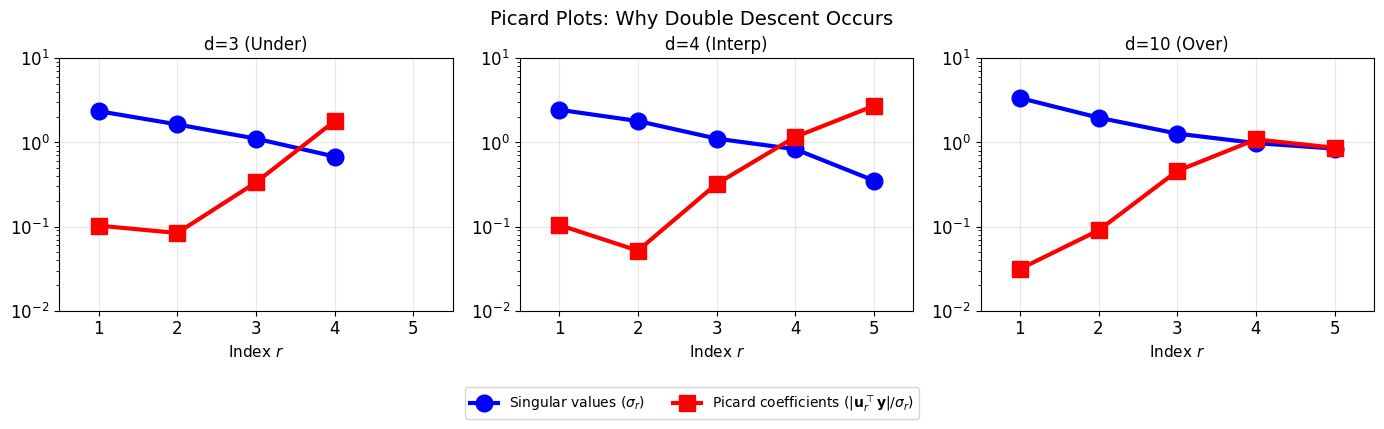

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, degree in zip(axes, svd_degrees):
    data = svd_results[degree]
    n_sv = len(data['singular_values'])
    indices = np.arange(1, n_sv + 1)

    # Singular values (blue circles)
    ax.semilogy(indices, data['singular_values'], 'o-', color='blue',
                linewidth=3, markersize=12, label='Singular values ($\\sigma_r$)')

    # Picard coefficients (red squares)
    ax.semilogy(indices, data['picard_ratios'], 's-', color='red',
                linewidth=3, markersize=12,
                label='Picard coefficients ($|\\mathbf{u}_r^\\top \\mathbf{y}|/\\sigma_r$)')

    ax.set_xlabel('Index $r$', fontsize=11)

    regime = "Under" if data['n_params'] < data['n_data'] else \
             "Interp" if data['n_params'] == data['n_data'] else "Over"
    ax.set_title(f'd={degree} ({regime})', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.01, 10)
    ax.set_xticks([1, 2, 3, 4, 5])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True, fancybox=True)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.suptitle('Picard Plots: Why Double Descent Occurs', fontsize=14, y=1.02)
plt.show()

## 7. Summary

### Key Takeaways

1. **Double descent is real**: Validation error peaks at the interpolation threshold, then decreases.

2. **Implicit regularization**: The minimum norm solution provides regularization by avoiding small singular value components.

3. **JAX reproducibility**: Using explicit PRNG keys ensures identical results across runs and platforms.

### Reproducibility Note

This notebook uses JAX's explicit PRNG system. To reproduce results:
- Use `MASTER_KEY = random.PRNGKey(42)`
- All noise realizations derive from this key via `random.split()`

In [10]:
# Print summary table
print("| Regime | Degree | Val Error (mean) | Solution Norm (mean) |")
print("|--------|--------|------------------|----------------------|")
for d in [1, 4, 10]:
    idx = d - MIN_DEGREE
    regime = "Under" if d < 4 else "Interp" if d == 4 else "Over"
    print(f"| {regime:6} | {d:6} | {val_mean[idx]:16.4f} | {norm_mean[idx]:20.4f} |")

| Regime | Degree | Val Error (mean) | Solution Norm (mean) |
|--------|--------|------------------|----------------------|
| Under  |      1 |           1.0520 |               0.4801 |
| Interp |      4 |           2.1733 |               4.0175 |
| Over   |     10 |           0.9021 |               1.8225 |
